# Extracting and Visualizing Stock Data — VERSION CORRIGÉE

Ce notebook est la version corrigée et complète de l'exercice IBM. Exécute chaque cellule dans l'ordre avec **Shift+Enter**.

## Setup — Installation et imports

In [1]:
!pip install yfinance
!pip install bs4
!pip install nbformat
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

print("Imports OK ✓")

Imports OK ✓


## Fonction make_graph

In [3]:
def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date),
                 stock_data_specific.Close.astype("float"),
                 label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date),
                 revenue_data_specific.Revenue.astype("float"),
                 label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

print("Fonction make_graph définie ✓")

Fonction make_graph définie ✓


## Question 1 — Use yfinance to Extract Tesla Stock Data

In [4]:
tesla = yf.Ticker("TSLA")

In [5]:
tesla_data = tesla.history(period="max")

In [6]:
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


## Question 2 — Use Webscraping to Extract Tesla Revenue Data

In [7]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data_tesla = requests.get(url).text

In [8]:
soup_tesla = BeautifulSoup(html_data_tesla, "html.parser")

In [9]:
# Créer le DataFrame vide
tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

# Isoler le tableau (index 1)
table = soup_tesla.find_all("tbody")[1]

# CORRECTIF : boucle qui remplit tesla_revenue ligne par ligne
for row in table.find_all("tr"):
    col = row.find_all("td")
    if len(col) != 0:
        date = col[0].text
        revenue = col[1].text
        tesla_revenue = pd.concat(
            [tesla_revenue, pd.DataFrame({"Date": [date], "Revenue": [revenue]})],
            ignore_index=True
        )

tesla_revenue.head()

,Date,Revenue
0,2022-09-30,"$21,454"
1,2022-06-30,"$16,934"
2,2022-03-31,"$18,756"
3,2021-12-31,"$17,719"
4,2021-09-30,"$13,757"


In [10]:
# Nettoyer la colonne Revenue : supprimer $ et virgules
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(',|\$', "", regex=True)

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\user\AppData\Local\Temp\ipykernel_5524\446828721.py:2: SyntaxWarning: invalid escape sequence '\$'
  tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(',|\$', "", regex=True)


In [11]:
# Supprimer les lignes vides ou nulles
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue["Revenue"] != ""]

tesla_revenue.tail()

,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


## Question 3 — Use yfinance to Extract GameStop Stock Data

In [12]:
# Nouvelle cellule à exécuter avant de re-télécharger GME
import yfinance as yf

# Force une nouvelle session sans cache
gme = yf.Ticker("GME")
gme_data = gme.history(period="max")

print("Shape:", gme_data.shape)
print(gme_data.head())

Shape: (6126, 7)
                               Open      High       Low     Close    Volume  \
Date                                                                          
2002-02-13 00:00:00-05:00  1.620128  1.693350  1.603296  1.691666  76216000   
2002-02-14 00:00:00-05:00  1.712707  1.716073  1.670625  1.683250  11021600   
2002-02-15 00:00:00-05:00  1.683250  1.687458  1.658001  1.674834   8389600   
2002-02-19 00:00:00-05:00  1.666417  1.666417  1.578047  1.607504   7410400   
2002-02-20 00:00:00-05:00  1.615920  1.662210  1.603296  1.662210   6892800   

                           Dividends  Stock Splits  
Date                                                
2002-02-13 00:00:00-05:00        0.0           0.0  
2002-02-14 00:00:00-05:00        0.0           0.0  
2002-02-15 00:00:00-05:00        0.0           0.0  
2002-02-19 00:00:00-05:00        0.0           0.0  
2002-02-20 00:00:00-05:00        0.0           0.0  


In [13]:
gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716073,1.670625,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666417,1.666417,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


## Question 4 — Use Webscraping to Extract GME Revenue Data

In [14]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_gme = requests.get(url).text

In [15]:
# CORRECTIF : soup_gme dédié au lieu de réutiliser soup_tesla
soup_gme = BeautifulSoup(html_data_gme, "html.parser")

In [16]:
# Créer le DataFrame vide
gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

# CORRECTIF : utiliser soup_gme (pas soup_tesla) pour avoir les vraies données GME
table_gme = soup_gme.find_all("tbody")[1]

for row in table_gme.find_all("tr"):
    col = row.find_all("td")
    if len(col) != 0:
        date = col[0].text
        revenue = col[1].text
        gme_revenue = pd.concat(
            [gme_revenue, pd.DataFrame({"Date": [date], "Revenue": [revenue]})],
            ignore_index=True
        )

gme_revenue.head()

,Date,Revenue
0,2020-04-30,"$1,021"
1,2020-01-31,"$2,194"
2,2019-10-31,"$1,439"
3,2019-07-31,"$1,286"
4,2019-04-30,"$1,548"


In [17]:
# Nettoyer la colonne Revenue
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(',|\$', "", regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]

gme_revenue.tail()

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\user\AppData\Local\Temp\ipykernel_5524\4182672882.py:2: SyntaxWarning: invalid escape sequence '\$'
  gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(',|\$', "", regex=True)


,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


## Vérifications demandées par l'exercice

In [18]:
# Dernière valeur de Revenue dans tesla_revenue
tesla_revenue["Revenue"].iloc[-1]

'27'

In [19]:
# Première ligne datée 2002-02-13 dans gme_revenue
gme_revenue[gme_revenue["Date"] == "2002-02-13"]

,Date,Revenue


In [20]:
# Première ligne de gme_revenue
gme_revenue.head(1)

,Date,Revenue
0,2020-04-30,1021


## Question 5 — Plot Tesla Stock Graph

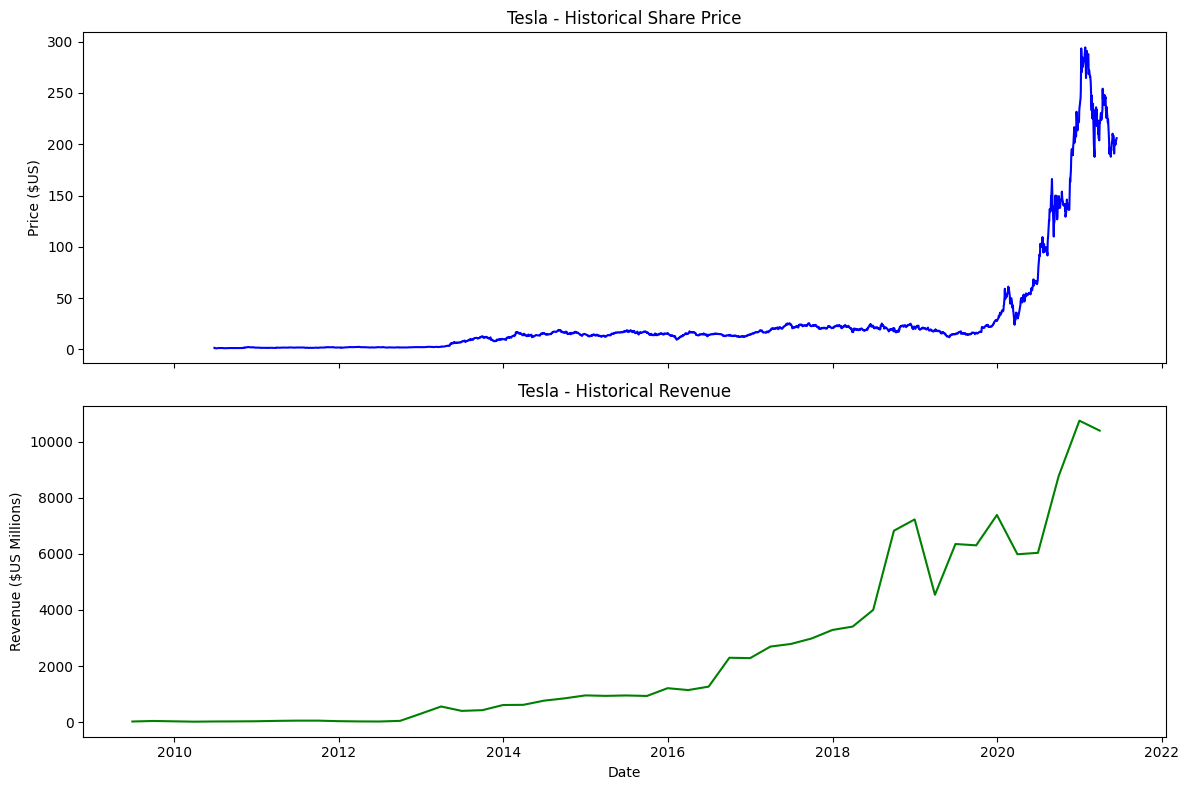

In [21]:
make_graph(tesla_data, tesla_revenue, "Tesla")

## Question 6 — Plot GameStop Stock Graph

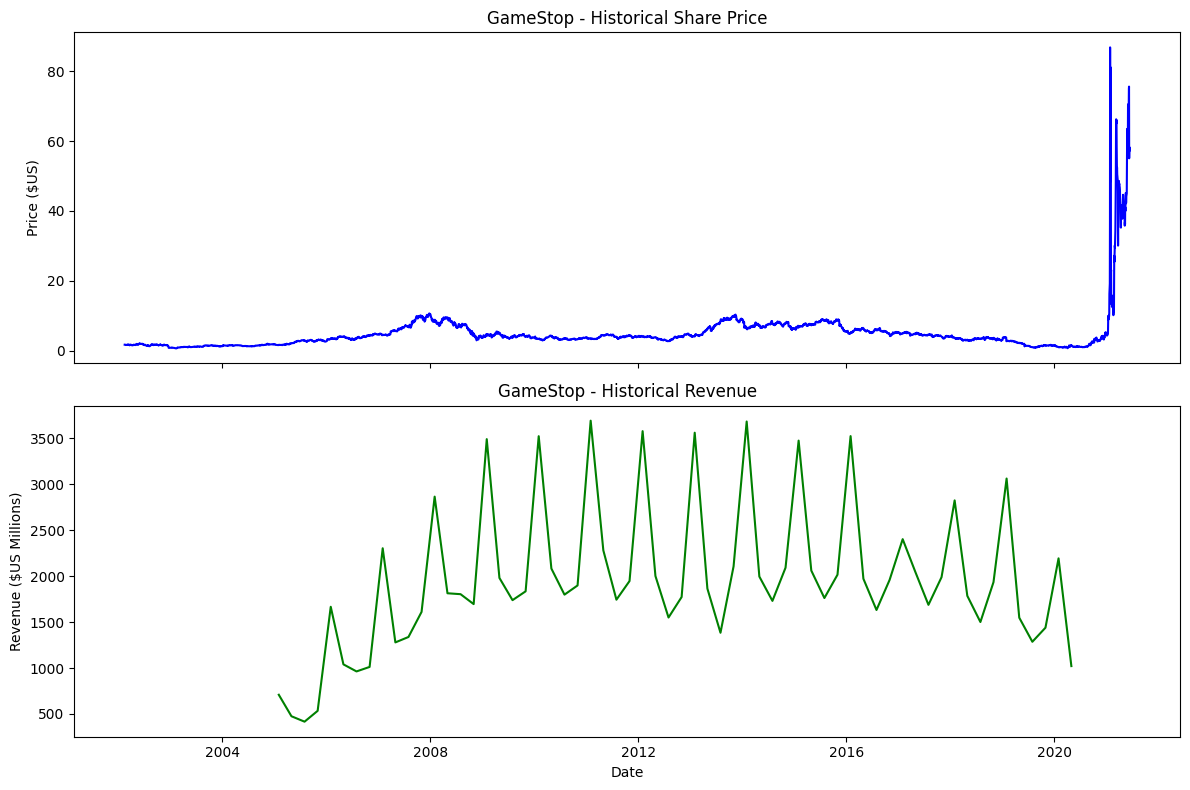

In [22]:
make_graph(gme_data, gme_revenue, "GameStop")